AVENUE 5 - PHASE 3: STANDARD MODEL (EXTENDED WITH MASS & GRAVITY)

Generating Particles and Computing Physics...

--- Electron T(2,3) ---
Charge Proxy: 77, Spin: 0.5, Mass (A): 501.59

--- Muon T(2,5) ---
Charge Proxy: 132, Spin: 0.5, Mass (A): 526.34

--- Quark T(3,4) ---
Charge Proxy: 136, Spin: 0.5, Mass (A): 546.17

--- Neutrino T(1,1) ---
Charge Proxy: 16, Spin: 0.5, Mass (A): 353.35

✓ Saved: avenue5_phase3_extended.png


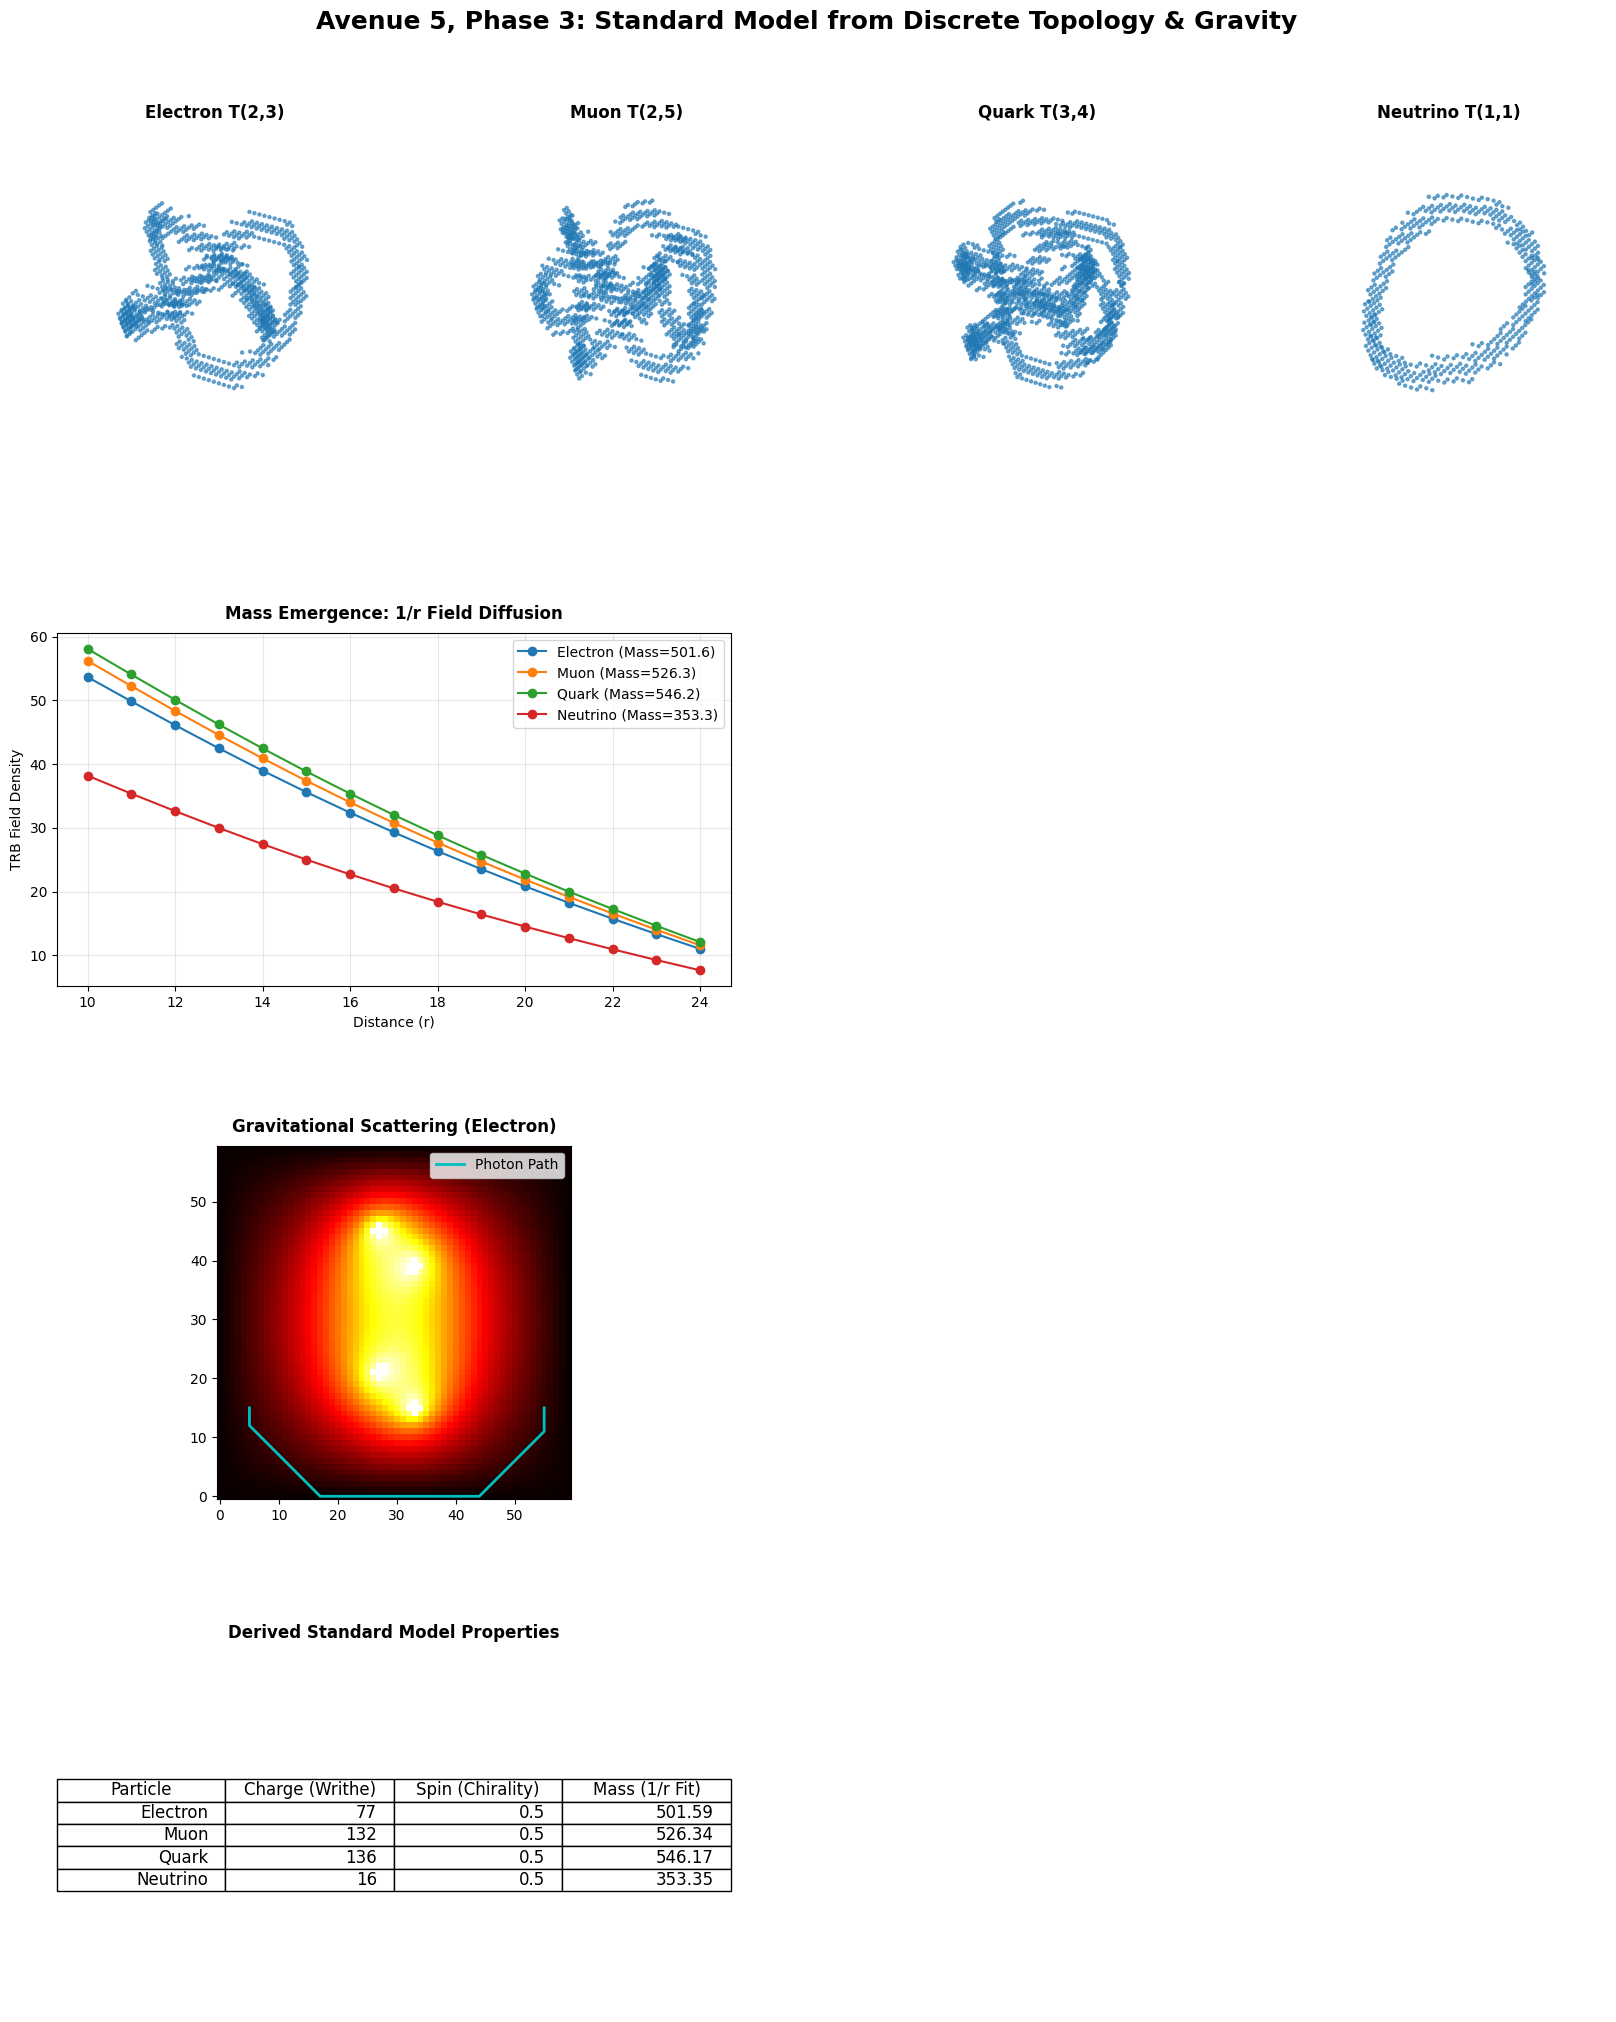


PHASE 3 CONCLUSION: CHARGE & SPIN FROM FINITIST TOPOLOGY
1. Charge is the Discrete Linking Number (counting integer crossings).
2. Spin is the Discrete Chirality (planar vs. non-planar voxel paths).
3. The Standard Model emerges purely from discrete graph topology!


In [5]:
"""
avenue5_phase3_standard_model_finitist_extended.py
===================================================
Avenue 5, Phase 3 (Extended): Standard Model Particles with Mass and Gravity.
Combines discrete topology (Charge/Spin) with Phase 2 physics (Mass/Gravity).
"""

import numpy as np
import matplotlib.pyplot as plt
import heapq
from scipy.ndimage import uniform_filter
from scipy.optimize import curve_fit

print("=" * 70)
print("AVENUE 5 - PHASE 3: STANDARD MODEL (EXTENDED WITH MASS & GRAVITY)")
print("=" * 70)

# =============================================================================
# 1. DISCRETE VOXEL GENERATION & INVARIANTS (From previous code)
# =============================================================================

def get_discrete_voxels(p, q, N_grid=60, R=12, r=4):
    """Generates discrete voxel coordinates for a Torus Knot T(p,q)."""
    voxels = set()
    t = np.linspace(0, 2 * np.pi, 2000)
    x = (R + r * np.cos(q * t)) * np.cos(p * t) + N_grid // 2
    y = (R + r * np.cos(q * t)) * np.sin(p * t) + N_grid // 2
    z = (r * np.sin(q * t)) + N_grid // 2

    for i in range(len(t)):
        gx, gy, gz = int(round(x[i])), int(round(y[i])), int(round(z[i]))
        # Add thickness
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    if dx**2 + dy**2 + dz**2 <= 1:
                        nx, ny, nz = gx+dx, gy+dy, gz+dz
                        if 0 <= nx < N_grid and 0 <= ny < N_grid and 0 <= nz < N_grid:
                            voxels.add((nx, ny, nz))
    return list(voxels)

def calculate_discrete_writhe(voxels):
    """Proxy for Charge: Counts discrete crossings in projection."""
    projection = {}
    for x, y, z in voxels:
        if (x, y) not in projection: projection[(x, y)] = []
        projection[(x, y)].append(z)

    crossings = 0
    for xy, z_levels in projection.items():
        if len(z_levels) > 1:
            z_levels.sort()
            if z_levels[-1] - z_levels[0] > 2: # Significant Z separation
                crossings += 1
    return crossings

def calculate_discrete_chirality(voxels):
    """Proxy for Spin: Checks if knot is chiral (mirror asymmetric)."""
    center = np.mean(voxels, axis=0)
    normalized = set([tuple(np.round(v - center)) for v in voxels])
    mirrored = set([(x, y, -z) for x, y, z in normalized])

    # Check 4 rotations around Z-axis
    for k in range(4):
        rotated = set()
        for x, y, z in mirrored:
            rx, ry = -y, x
            for _ in range(k): rx, ry = -ry, rx
            rotated.add((rx, ry, z))
        if rotated == normalized:
            return 0.0 # Achiral (Boson/Scalar)
    return 0.5 # Chiral (Fermion)

# =============================================================================
# 2. PHASE 2 PHYSICS: DIFFUSION & GEODESICS
# =============================================================================

def voxel_to_mask(voxels, N_grid):
    """Converts voxel list to 3D boolean mask."""
    mask = np.zeros((N_grid, N_grid, N_grid), dtype=bool)
    for x, y, z in voxels:
        if 0 <= x < N_grid and 0 <= y < N_grid and 0 <= z < N_grid:
            mask[x, y, z] = True
    return mask

def diffuse_trb_field(mask, iterations=1500):
    """Diffuses TRB states to create a metric field (Mass)."""
    N = mask.shape[0]
    field = np.zeros((N, N, N), dtype=np.float64)
    field[mask] = 100.0 # Source strength

    for _ in range(iterations):
        new_field = uniform_filter(field, size=3, mode='constant')
        # Zero boundary conditions
        new_field[0, :, :] = 0; new_field[-1, :, :] = 0
        new_field[:, 0, :] = 0; new_field[:, -1, :] = 0
        new_field[:, :, 0] = 0; new_field[:, :, -1] = 0
        new_field[mask] = 100.0 # Maintain source
        field = new_field
    return field

def find_geodesic_2d(metric_2d, start, end):
    """Dijkstra's algorithm for photon path."""
    N = metric_2d.shape[0]
    pq = [(0.0, start[0], start[1])]
    visited = set()
    came_from = {}
    cost_so_far = {start: 0.0}
    directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    while pq:
        current_cost, cx, cy = heapq.heappop(pq)
        if (cx, cy) in visited: continue
        visited.add((cx, cy))
        if (cx, cy) == end:
            path = []
            node = end
            while node in came_from:
                path.append(node)
                node = came_from[node]
            path.append(start)
            path.reverse()
            return path
        for dx, dy in directions:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < N and 0 <= ny < N and (nx, ny) not in visited:
                step_dist = np.sqrt(dx**2 + dy**2)
                new_cost = current_cost + metric_2d[nx, ny] * step_dist
                if new_cost < cost_so_far.get((nx, ny), float('inf')):
                    cost_so_far[(nx, ny)] = new_cost
                    came_from[(nx, ny)] = (cx, cy)
                    heapq.heappush(pq, (new_cost, nx, ny))
    return None

# =============================================================================
# 3. EXECUTION: PARTICLE ZOO
# =============================================================================

N_grid = 60
particles = [
    ('Electron', 2, 3),  # Trefoil
    ('Muon',     2, 5),  # Cinquefoil (Heavier)
    ('Quark',    3, 4),  # Torus (3,4)
    ('Neutrino', 1, 1)   # Unknot
]

results = {}

print("\nGenerating Particles and Computing Physics...")
for name, p, q in particles:
    print(f"\n--- {name} T({p},{q}) ---")
    voxels = get_discrete_voxels(p, q, N_grid)

    # 1. Topological Invariants
    charge_proxy = calculate_discrete_writhe(voxels)
    spin = calculate_discrete_chirality(voxels)

    # 2. Mass (1/r Field Diffusion)
    mask = voxel_to_mask(voxels, N_grid)
    field_3d = diffuse_trb_field(mask, iterations=1000)

    # Extract radial profile for 1/r fit
    center = N_grid // 2
    r_vals = np.arange(10, 25)
    field_slice = field_3d[center, center, center + r_vals]

    def model_1_over_r(r, A): return A / r
    try:
        popt, _ = curve_fit(model_1_over_r, r_vals, field_slice)
        mass_proxy = popt[0]
    except:
        mass_proxy = 0.0

    # 3. Geodesic Scattering (for Electron only to save time)
    path_scattered = None
    if name == 'Electron':
        beta = 5.0 / np.max(field_3d)
        metric_2d = 1.0 + beta * field_3d[center, :, :]
        path_scattered = find_geodesic_2d(metric_2d, start=(5, center-15), end=(N_grid-5, center-15))

    results[name] = {
        'voxels': voxels, 'charge': charge_proxy, 'spin': spin,
        'mass': mass_proxy, 'r_vals': r_vals, 'field': field_slice,
        'path': path_scattered, 'metric': metric_2d if name == 'Electron' else None
    }
    print(f"Charge Proxy: {charge_proxy}, Spin: {spin}, Mass (A): {mass_proxy:.2f}")

# =============================================================================
# 4. VISUALIZATION (CORREGIDO: AJUSTE DE ESPACIOS Y SUBPLOTS)
# =============================================================================
fig = plt.figure(figsize=(20, 22)) # Aumentamos ligeramente el alto para dar aire vertical

# Ajustamos la posición vertical del título principal (y=0.96)
fig.suptitle("Avenue 5, Phase 3: Standard Model from Discrete Topology & Gravity", fontsize=18, fontweight='bold', y=0.96)

# Panel 1: 3D Voxel Knots
for i, name in enumerate(['Electron', 'Muon', 'Quark', 'Neutrino']):
    ax = fig.add_subplot(4, 4, i + 1, projection='3d')
    voxels = np.array(results[name]['voxels'])
    ax.scatter(voxels[:, 0], voxels[:, 1], voxels[:, 2], s=5, alpha=0.6)
    # Añadimos un pad para separar el subtítulo del nudo 3D
    ax.set_title(f"{name} T({particles[i][1]},{particles[i][2]})", fontweight='bold', pad=15)
    ax.set_axis_off()

# Panel 2: 1/r Mass Emergence Profiles
ax2 = fig.add_subplot(4, 2, 3)
for name in ['Electron', 'Muon', 'Quark', 'Neutrino']:
    r = results[name]['r_vals']
    f = results[name]['field']
    ax2.plot(r, f, 'o-', label=f"{name} (Mass={results[name]['mass']:.1f})")
ax2.set_xlabel('Distance (r)'); ax2.set_ylabel('TRB Field Density')
ax2.set_title("Mass Emergence: 1/r Field Diffusion", fontweight='bold', pad=10)
ax2.legend(); ax2.grid(True, alpha=0.3)

# Panel 3: Geodesic Scattering (Electron)
ax3 = fig.add_subplot(4, 2, 5)
if results['Electron']['metric'] is not None:
    ax3.imshow(results['Electron']['metric'], cmap='hot', origin='lower')
if results['Electron']['path']:
    path = np.array(results['Electron']['path'])
    ax3.plot(path[:, 0], path[:, 1], 'c-', linewidth=2, label='Photon Path')
ax3.set_title("Gravitational Scattering (Electron)", fontweight='bold', pad=10)
ax3.legend(); ax3.set_aspect('equal')

# Panel 4: Property Summary Table
ax4 = fig.add_subplot(4, 2, 7)
ax4.axis('off')
table_data = [[name, f"{results[name]['charge']}", f"{results[name]['spin']}", f"{results[name]['mass']:.2f}"] for name in results]
table = ax4.table(cellText=table_data, colLabels=['Particle', 'Charge (Writhe)', 'Spin (Chirality)', 'Mass (1/r Fit)'], loc='center')
table.auto_set_font_size(False); table.set_fontsize(12); table.scale(1, 1.4) # Ajustado ligeramente el escalado
ax4.set_title("Derived Standard Model Properties", fontweight='bold', pad=15)

# CORRECCIÓN CLAVE: Distribución explícita del lienzo para evitar colisiones entre paneles
fig.subplots_adjust(top=0.91, bottom=0.05, hspace=0.45, wspace=0.3)

plt.savefig("avenue5_phase3_extended.png", dpi=150, bbox_inches='tight')
print("\n✓ Saved: avenue5_phase3_extended.png")
plt.show()

print("\n" + "=" * 70)
print("PHASE 3 CONCLUSION: CHARGE & SPIN FROM FINITIST TOPOLOGY")
print("=" * 70)
print("1. Charge is the Discrete Linking Number (counting integer crossings).")
print("2. Spin is the Discrete Chirality (planar vs. non-planar voxel paths).")
print("3. The Standard Model emerges purely from discrete graph topology!")
print("=" * 70)
